# **Analysis of FDA approved pharmaceuticals**
Summer I 2026 Data Science Project

Ryan Stein, Siaf Haider, William Wang, Joseph Sherman

### **Contributions**
**Project idea**:
- Formal Write for P1 Regarding What Dataset (Chosen by {}) we will use, why we chose it, and what we planned to get out of it (RYAN)

**Dataset Curation and Preprocessing**: Joseph - I imported and loaded the dataset into a dataframe. I also cleaned and parsed the data.

**Data Exploration and Summary Statistics**:
- manufacturer market-concentration analysis (top-10 makers, HHI, single-product-company breakdown (RYAN)

**ML Algorithm Design/Development**: Joseph - I designed the TF-IDF + KMeans clustering approach to test whether drug warning text aligns with known categories like product type.

**ML Algorithm Training and Test Data Analysis**: Joseph - I vectorized the warning text, used the elbow method to choose k, and evaluated the resulting clusters against product type.

**Visualization, Result Analysis, Conclusion**:
- Created conclusion tying all four of our questions into a single analysis (RYAN)
- Create the cluster-compsotion visualization (RYAN)
- Create the TF-IDF term visualization (RYAN)

**Final Tutorial Report Creation**: 
- Joseph - I added explanatory text and formatting to the overall project.
- Reworded Introduction to allign w/ analysis & visualization methods (RYAN)


## **Introduction**

The point of this project is to unveil underlying trends in FDA-approved drugs — who makes them, how they're marketed, and how they're labeled — to make thousands of drug labels easier to interpret. Using the openFDA Drug Label dataset, we explore four primary questions:

1. How concentrated is the drug-label market — is it controlled by a few big players, or partitioned among numerous smaller ones?
2. How does a drug's route of administration relate to its warnings and to whether it's flagged as safe or unsafe during pregnancy and breastfeeding?
3. Do drugs with longer warning sections also have longer dosage and administration instructions?
4. Can the language of a drug's warnings alone reveal its product category (e.g. OTC vs. prescription)?   

### Tools
The following tools should be imported:

- Pandas
- NumPy
- Requests
- MatPlotLib

In [74]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

## Data Curation

**Source.** Our data comes from the [openFDA Drug Label API](https://api.fda.gov/drug/label.json), which mirrors the FDA's Structured Product Labeling (SPL) submissions for drugs marketed in the United States. Each record corresponds to one drug label and includes fields such as active/inactive ingredients, purpose, warnings, dosage and administration instructions, pregnancy/breastfeeding guidance, route of administration, and manufacturer.

**Collection.** We paginated through the API in batches of 1,000 records (see the cell below, which only needs to be run once) and saved the combined results to `drug.csv` so the rest of the notebook can work from a local file instead of re-querying the API every time.

**Cleaning and transformation.** After loading `drug.csv` into a DataFrame, we:
- Check for and drop fully duplicated rows.
- Select the subset of columns relevant to our questions (ingredients, purpose, warnings, dosage/administration, pregnancy/breastfeeding guidance, route, manufacturer, etc.).
- Lowercase and strip boilerplate/HTML artifacts from free-text fields (e.g. `warnings`, `purpose`, `dosage_and_administration`).
- Fill missing `active_ingredient` values from `spl_product_data_elements` where possible, then drop the now-redundant column.
- Bucket several free-text fields (e.g. `do_not_use`, `openfda.route`, stop-use/ask-a-doctor language) into consistent categories using small helper functions, so they can be grouped and compared later.

The result, `drug_df`, is the cleaned DataFrame used throughout the rest of the analysis.

In [7]:
#DON'T RUN THIS
import pandas as pd
import requests

all_drugs = []
num = 0

while True:
    drug_data = requests.get(f"https://api.fda.gov/drug/label.json?limit=1000&skip={num}").json()

    if 'results' not in drug_data:
        break

    all_drugs.extend(drug_data['results'])
    num += 1000

drug_df = pd.json_normalize(all_drugs)
drug_df.to_csv('drug.csv', index=False)

KeyboardInterrupt: 

In [75]:
# RUN THIS
df = pd.read_csv("drug.csv", low_memory=False)
df

,effective_time,inactive_ingredient,purpose,keep_out_of_reach_of_children,warnings,questions,spl_product_data_elements,version,dosage_and_administration,pregnancy_or_breast_feeding,...,health_care_provider_letter_table,guaranteed_analysis_of_feed,troubleshooting,nonteratogenic_effects_table,safe_handling_warning_table,nursing_mothers_table,spl_indexing_data_elements,teratogenic_effects_table,health_claim_table,spl_indexing_data_elements_table
0,20210902,['INACTIVE INGREDIENTS Sucrose'],"['USES USES: Temporary Relief - Acne, Boils* *...",['Keep this and all medication out of reach of...,['WARNINGS This product is to be used for self...,['QUESTIONS OR COMMENTS www.Rxhomeo.com | 1.88...,['SILICEA SILICEA SUCROSE SILICON DIOXIDE SILI...,2,"['DOSAGE Adults- Take 4 or 6 Pellets by mouth,...","['As with any drug, if you are pregnant, or nu...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20150109,"['INGREDIENTS: TALC, POLYMETHYL METHACRYLATE, ...",['Purpose Sunscreen'],['Keep out of reach of children If product is ...,['Warnings For external use only.'],NaN,['CHANTECAILLE PROTECTION NATURELLE BRONZE SPF...,4,['Directions Protection Naturelle SPF 46 PA+++...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20250102,"['Inactive ingredients pareth 25-9, purified w...",['Purpose First aid Antiseptic'],"['Keep out of reach of children If swallowed, ...",['Warnings For external use only'],NaN,['Betadine POVIDONE-IODINE POVIDONE-IODINE IOD...,1,['Directions clean the affected area spray a s...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20230802,['INACTIVE INGREDIENTS Sucrose/Lactose'],['USES To relieve the symptoms of itching.'],['KEEP OUT OF REACH OF CHILDREN Keep this and ...,['STOP USE AND ASK DOCTOR If symptoms persist/...,NaN,['Mezereum DAPHNE MEZEREUM BARK SUCROSE LACTOS...,3,['DIRECTIONS Adults: Dissolve 3 to 5 under the...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,20230905,NaN,NaN,NaN,['WARNINGS NOT FOR INJECTION. Ofloxacin ophtha...,NaN,['Ofloxacin Ofloxacin OFLOXACIN OFLOXACIN Sodi...,7,['DOSAGE AND ADMINISTRATION The recommended do...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25995,20240611,['Inactive ingredients Aloe Barbadensis (Aloe ...,['Purpose Sunscreen'],"['Keep out of reach of children. If swallowed,...",['Warnings For external use only Do not use on...,NaN,"['Matte Sunscreen SPF 50 Titanium Dioxide, Zin...",1,['Directions • apply liberally 15 minutes befo...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25996,20240611,"['Water (Aqua, Eau), Fragrance (Parfum), Carbo...",['Purpose Antiseptic'],"['Keep out of reach of children. If swallowed,...",['Warnings Flammable: Keep away from flame or ...,NaN,['Anti Bacterial Hand Gel Fresh Cut Lilacs Alc...,1,['Directions Rub a dime sized drop into hands.'],NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25997,20240611,"['Water (Aqua, Eau), Fragrance (Parfum), Carbo...",['Purpose Antiseptic'],"['Keep out of reach of children. If swallowed,...",['Warnings Flammable: Keep away from flame or ...,NaN,['Anti Bacterial Hand Gel Ghoul Friend Alcohol...,1,['Directions Rub a dime sized drop into hands.'],NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25998,20181218,NaN,NaN,NaN,['WARNINGS PROPHYLACTIC BLADDER CARE WITH NEOS...,NaN,['NEOSPORIN G.U. neomycin sulfate - polymyxin ...,8,['DOSAGE AND ADMINISTRATION This preparation i...,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


We check the dataset's dimensions before cleaning it.

In [76]:
df.shape

(26000, 165)

We inspect the available column names.

In [77]:
df.columns

Index(['effective_time', 'inactive_ingredient', 'purpose',
       'keep_out_of_reach_of_children', 'warnings', 'questions',
       'spl_product_data_elements', 'version', 'dosage_and_administration',
       'pregnancy_or_breast_feeding',
       ...
       'health_care_provider_letter_table', 'guaranteed_analysis_of_feed',
       'troubleshooting', 'nonteratogenic_effects_table',
       'safe_handling_warning_table', 'nursing_mothers_table',
       'spl_indexing_data_elements', 'teratogenic_effects_table',
       'health_claim_table', 'spl_indexing_data_elements_table'],
      dtype='str', length=165)

In [78]:
# Dup Check

# All Features Values Shared
print("Full Dups:", df.duplicated().sum())

# UID (doc, product) shared
print("Dup 'id' values:    ", df['id'].duplicated().sum())
print("Dup 'set_id'(product) values:", df['set_id'].duplicated().sum())

# Drop triggered from above
_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f" Pre-Dedup Ct. : {_before} | Post-Dedup Ct. : {len(df)} | (Dropped {_before - len(df)} Dups)")

Full Dups: 0
Dup 'id' values:     0
Dup 'set_id'(product) values: 0
 Pre-Dedup Ct. : 26000 | Post-Dedup Ct. : 26000 | (Dropped 0 Dups)


We narrow the raw dataframe down to the columns relevant to our questions, such as ingredients, purpose, warnings, dosage, pregnancy guidance, route, and manufacturer.

In [79]:
drug_df = df[['inactive_ingredient', 'purpose', 'warnings',
       'spl_product_data_elements', 'dosage_and_administration',
       'pregnancy_or_breast_feeding', 'stop_use', 'storage_and_handling',
       'do_not_use', 'active_ingredient', 'openfda.brand_name',
       'openfda.manufacturer_name', 'openfda.product_type', 'openfda.route',
       'openfda.package_ndc', 'when_using', 'ask_doctor',
       'clinical_studies',
       'adverse_reactions']]

We confirm the number of columns kept after selecting our subset.

In [80]:
drug_df.shape

(26000, 19)

We confirm which columns we kept.

In [81]:
drug_df.columns

Index(['inactive_ingredient', 'purpose', 'warnings',
       'spl_product_data_elements', 'dosage_and_administration',
       'pregnancy_or_breast_feeding', 'stop_use', 'storage_and_handling',
       'do_not_use', 'active_ingredient', 'openfda.brand_name',
       'openfda.manufacturer_name', 'openfda.product_type', 'openfda.route',
       'openfda.package_ndc', 'when_using', 'ask_doctor', 'clinical_studies',
       'adverse_reactions'],
      dtype='str')

We clean the 'inactive_ingredient' column by lowercasing it and stripping boilerplate header words and stray punctuation left over from the API's list-like formatting, such as brackets, quotes, and colons.

In [82]:
drug_df['inactive_ingredient'] = drug_df['inactive_ingredient'].str.lower().str.replace("ingredients", '').str.replace("inactive", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()
drug_df['inactive_ingredient']

0                                                  sucrose
1        talc, polymethyl methacrylate, vinyl dimethico...
2        pareth 25-9, purified water, sodium hydroxide ...
3                                          sucrose/lactose
4                                                      NaN
                               ...                        
25995    aloe barbadensis (aloe vera) leaf extract, alu...
25996    water (aqua, eau), fragrance (parfum), carbome...
25997    water (aqua, eau), fragrance (parfum), carbome...
25998                                                  NaN
25999    water (aqua, eau), isopropyl alcohol, fragranc...
Name: inactive_ingredient, Length: 26000, dtype: str

We clean the 'purpose' column by lowercasing it and stripping the "Uses" header and punctuation so only the actual purpose text remains.

In [83]:
drug_df['purpose'] = drug_df['purpose'].str.lower().str.replace("uses", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()
drug_df['purpose']

0        temporary relief - acne, boils* * claims based...
1                                        purpose sunscreen
2                             purpose first aid antiseptic
3                      to relieve the symptoms of itching.
4                                                      NaN
                               ...                        
25995                                    purpose sunscreen
25996                                   purpose antiseptic
25997                                   purpose antiseptic
25998                                                  NaN
25999                                   purpose antiseptic
Name: purpose, Length: 26000, dtype: str

We clean the 'warnings' column by lowercasing it and stripping the "Warnings" header and punctuation so only the warning text itself remains.

In [84]:
drug_df['warnings'] = drug_df['warnings'].str.lower().str.replace("warnings", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()
drug_df['warnings']

0        this product is to be used for self-limiting c...
1                                   for external use only.
2                                    for external use only
3        stop use and ask doctor if symptoms persist/wo...
4        not for injection. ofloxacin ophthalmic soluti...
                               ...                        
25995    for external use only do not use on damaged or...
25996    flammable keep away from flame or high heat., ...
25997    flammable keep away from flame or high heat., ...
25998    prophylactic bladder care with neosporin g.u. ...
25999    for external use only . when using this produc...
Name: warnings, Length: 26000, dtype: str

We clean the 'spl_product_data_elements' column the same way and then remove repeated words within each entry, since the API sometimes repeats the same phrase multiple times per record.

In [85]:
drug_df['spl_product_data_elements'] = drug_df['spl_product_data_elements'].str.lower().str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()
drug_df['spl_product_data_elements'] = drug_df['spl_product_data_elements'].apply(lambda x: ' '.join(dict.fromkeys(str(x).split())))
drug_df['spl_product_data_elements']

0                          silicea sucrose silicon dioxide
1        chantecaille protection naturelle bronze spf 4...
2        betadine povidone-iodine iodine c12-15 pareth-...
3               mezereum daphne bark sucrose lactose white
4        ofloxacin sodium chloride hydrochloric acid hy...
                               ...                        
25995    matte sunscreen spf 50 titanium dioxide, zinc ...
25996    anti bacterial hand gel fresh cut lilacs alcoh...
25997    anti bacterial hand gel ghoul friend alcohol w...
25998        neosporin g.u. neomycin sulfate - polymyxin b
25999              anti-bacterial hand virgo alcohol water
Name: spl_product_data_elements, Length: 26000, dtype: str

We clean the 'active_ingredient' column by stripping "Drug Facts" and "Active Ingredients" boilerplate along with parenthetical dosage notes, such as "(in each gram)", so only the ingredient names remain.

In [86]:
drug_df['active_ingredient'] = drug_df['active_ingredient'].str.lower().str.replace("ingredients", '').str.replace("drug facts", '').str.replace("active", '').str.replace("drug fact", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '')
drug_df['active_ingredient'] = drug_df['active_ingredient'].str.replace("in each gram", '').str.replace("(", '').str.replace(")", '').str.strip()
drug_df['active_ingredient']

0                    ingredient silicea hpus 2x and higher
1        bronze   titanium dioxide 2 %, ethylhexyl meth...
2                povidone-iodine, 5% 0.5% available iodine
3                                                 mezereum
4                                                      NaN
                               ...                        
25995               titanium dioxide 5.8% zinc oxide 14.4%
25996                               ingredient alcohol 71%
25997                               ingredient alcohol 71%
25998                                                  NaN
25999                               ingredient alcohol 68%
Name: active_ingredient, Length: 26000, dtype: str

Some records only listed the active ingredient inside 'spl_product_data_elements' instead of 'active_ingredient', so we backfill the missing values from that column.

In [87]:
drug_df['active_ingredient'] = drug_df['active_ingredient'].fillna(drug_df['spl_product_data_elements'])

We spot-check the cleaned active ingredient values and then drop the 'spl_product_data_elements' column, since its useful information has already been merged into 'active_ingredient'.

In [88]:
drug_df['active_ingredient'].value_counts()
drug_df = drug_df.drop(columns = 'spl_product_data_elements')

We clean the 'dosage_and_administration' column by stripping boilerplate headers, such as "Dosage and Administration" and "Directions", along with formatting characters like bullets and quotes.

In [89]:
drug_df['dosage_and_administration'] = drug_df['dosage_and_administration'].str.lower().str.replace("ingredients", '').str.replace("drug facts", '').str.replace("active", '').str.replace("drug fact", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '')
drug_df['dosage_and_administration'] = drug_df['dosage_and_administration'].str.replace('dosage and administration', '').str.replace('directions', '').str.replace('dosage', '').str.replace('•', '').str.replace('"', '').str.strip()
drug_df['dosage_and_administration']

0        adults- take 4 or 6 pellets by mouth, three ti...
1        protection naturelle spf 46 pa+++ powder can b...
2        clean the affected area spray a small amount o...
3        adults dissolve 3 to 5 under the tongue three ...
4        the recommended  regimen for the treatment of ...
                               ...                        
25995    apply liberally 15 minutes before sun exposure...
25996                    rub a dime sized drop into hands.
25997                    rub a dime sized drop into hands.
25998    this preparation is specifically designed for ...
25999                    rub a dime sized drop into hands.
Name: dosage_and_administration, Length: 26000, dtype: str

We recode the 'pregnancy_or_breast_feeding' column. Since a non-null value in the raw data means a caution or warning was present, we map present values to 'Bad' and missing values to 'Fine'.

In [90]:
drug_df.loc[drug_df['pregnancy_or_breast_feeding'].notna(), 'pregnancy_or_breast_feeding'] = 'Bad'
drug_df['pregnancy_or_breast_feeding'] = drug_df['pregnancy_or_breast_feeding'].fillna('Fine')
drug_df['pregnancy_or_breast_feeding']

0         Bad
1        Fine
2        Fine
3        Fine
4        Fine
         ... 
25995    Fine
25996    Fine
25997    Fine
25998    Fine
25999    Fine
Name: pregnancy_or_breast_feeding, Length: 26000, dtype: str

We bucket the free-text 'stop_use' reasons into a small set of consistent categories, such as rash, allergic reaction, and irritation, so they can be grouped and compared later.

In [91]:
def categorize_stop_use(text):
    if pd.isna(text):
        return np.nan
    text = text.lower()
    if 'rash' in text:
        return 'rash'
    elif 'allergic' in text:
        return 'allergic reaction'
    elif 'irritat' in text:
        return 'irritation'
    elif 'rectal bleeding' in text or 'bowel' in text:
        return 'rectal bleeding or bowel movement problems'
    elif 'dry' in text:
        return 'dry'
    elif 'days' in text or 'week' in text or 'persist' in text or 'improve' in text or 'regular' in text:
        return 'symptoms persist after some time'
    elif 'do not use' in text:
        return np.nan
    else:
        return 'other'

drug_df['stop_use'] = drug_df['stop_use'].apply(lambda x: categorize_stop_use(x))
drug_df['stop_use'].value_counts()

stop_use
rash                                          3398
symptoms persist after some time              2481
irritation                                    1691
allergic reaction                              536
rectal bleeding or bowel movement problems     341
other                                          254
dry                                              6
Name: count, dtype: int64

We clean the 'storage_and_handling' column by stripping boilerplate headers and punctuation, along with the "Other Information" section label that sometimes prefixes this field.

In [92]:
drug_df['storage_and_handling'] = drug_df['storage_and_handling'].str.lower().str.replace("ingredients", '').str.replace("drug facts", '').str.replace("active", '').str.replace("drug fact", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '')
drug_df['storage_and_handling'] = drug_df['storage_and_handling'].str.replace('other information', '')
drug_df['storage_and_handling']

0                       storage store in a cool dark place
1                                                      NaN
2         store at 25⁰c (77⁰f); excursions permitted be...
3                                                      NaN
4                                                      NaN
                               ...                        
25995                                                  NaN
25996                                                  NaN
25997                                                  NaN
25998                    store at 2° to 8°c (36° to 46°f).
25999                                                  NaN
Name: storage_and_handling, Length: 26000, dtype: str

We clean the 'do_not_use' column by stripping the "Do Not Use" header and punctuation. Since drugs with no do_not_use text are generally OK to use, we fill missing values with 'use'.

In [93]:
drug_df['do_not_use'] = drug_df['do_not_use'].str.lower().str.replace('do not use', '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()
drug_df['do_not_use'] = drug_df['do_not_use'].fillna('use')
drug_df['do_not_use']

0        if capseal is broken or missing. close the cap...
1                                                      use
2        in the eyes over large areas of the body if yo...
3                                                      use
4                                                      use
                               ...                        
25995                            on damaged or broken skin
25996                                                  use
25997                                                  use
25998                                                  use
25999                                                  use
Name: do_not_use, Length: 26000, dtype: str

We clean the 'openfda.brand_name' column and rename it to 'brand_name'.

In [94]:
drug_df['openfda.brand_name'] = drug_df['openfda.brand_name'].str.lower().str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()
drug_df['brand_name'] = drug_df['openfda.brand_name']
drug_df = drug_df.drop(columns = ['openfda.brand_name'])
drug_df['brand_name']

0                                         silicea
1                                             NaN
2                                        betadine
3                                             NaN
4                                             NaN
                           ...                   
25995                                         NaN
25996    anti bacterial hand gel fresh cut lilacs
25997        anti bacterial hand gel ghoul friend
25998                                         NaN
25999                                         NaN
Name: brand_name, Length: 26000, dtype: str

We clean manufacturer names by dropping legal suffixes like LLC, Inc, Co, and Ltd along with punctuation, so the same company isn't split across multiple spellings, and then rename 'openfda.manufacturer_name' to 'manufacturer_name'.

In [95]:
drug_df['openfda.manufacturer_name'] = drug_df['openfda.manufacturer_name'].str.lower().str.replace(".", '').str.replace("llc", '').str.replace(",", '').str.replace("inc", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()
drug_df['openfda.manufacturer_name'] = drug_df['openfda.manufacturer_name'].str.replace("co", '').str.replace("ltd", '')
drug_df['manufacturer_name'] = drug_df['openfda.manufacturer_name']
drug_df = drug_df.drop(columns = ['openfda.manufacturer_name'])
drug_df['manufacturer_name']

0        rxhomeo private limited dba rxhomeo
1                                        NaN
2                 atlantis nsumer healthcare
3                                        NaN
4                                        NaN
                        ...                 
25995                                    NaN
25996                      bath & body works
25997                      bath & body works
25998                                    NaN
25999                                    NaN
Name: manufacturer_name, Length: 26000, dtype: str

We bucket the 'openfda.product_type' column into OTC, prescription, or cellular therapy categories, and then drop the raw column now that 'product_type' replaces it.

In [96]:
def categorize_product_type(text):
    if pd.isna(text):
        return np.nan
    text = text.lower()
    if 'otc' in text:
        return 'OTC'
    elif 'prescription' in text:
        return 'prescription'
    elif 'cellular therapy' in text:
        return 'cellular therapy'

drug_df['product_type'] = drug_df['openfda.product_type'].apply(lambda x: categorize_product_type(x))
drug_df = drug_df.drop(columns = ['openfda.product_type'])
drug_df['product_type']

0        OTC
1        NaN
2        OTC
3        NaN
4        NaN
        ... 
25995    NaN
25996    OTC
25997    OTC
25998    NaN
25999    NaN
Name: product_type, Length: 26000, dtype: str

We clean the 'openfda.route' column and rename it to 'route'.

In [97]:
drug_df['openfda.route'] = drug_df['openfda.route'].str.lower().str.replace(".", '').str.replace("llc", '').str.replace(",", '').str.replace("inc", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()
drug_df['route'] = drug_df['openfda.route']
drug_df = drug_df.drop(columns = ['openfda.route'])
drug_df['route']

0           oral
1            NaN
2        topical
3            NaN
4            NaN
          ...   
25995        NaN
25996    topical
25997    topical
25998        NaN
25999        NaN
Name: route, Length: 26000, dtype: str

We bucket the free-text 'when_using' warnings into a small set of consistent categories, such as eye contact, alcohol, dosage limits, and food or milk.

In [98]:
def categorize_when_using(text):
    if pd.isna(text):
        return np.nan
    text = text.lower()
    if 'eyes' in text:
        return 'keep out of eyes'
    elif 'alcohol' in text:
        return 'avoid alcoholic beverages'
    elif 'caffine' in text:
        return 'avoid caffine'
    elif 'more than' in text or 'dosage' in text or 'dose' in text:
        return 'do not take more than directed'
    elif 'food or milk' in text:
        return 'take with food or milk if stomach upset'
    else:
        return 'other'

drug_df['when_using'] = drug_df['when_using'].apply(lambda x: categorize_when_using(x))
drug_df['when_using'].value_counts()

when_using
keep out of eyes                           4450
other                                      1042
do not take more than directed             1004
avoid alcoholic beverages                   736
take with food or milk if stomach upset     178
Name: count, dtype: int64

We bucket the free-text 'ask_doctor' guidance into a small set of consistent categories, such as liver or kidney disease and breathing issues.

In [99]:
def categorize_ask_doctor(text):
    if pd.isna(text) or text == "['']":
        return np.nan
    text = text.lower()
    if 'liver' in text and 'kidney' in text:
        return 'if you have liver or kidney disease'
    elif 'liver' in text and not 'kidney' in text:
        return 'if you have liver disease'
    elif 'kidney' in text and not 'liver' in text:
        return 'if you have kidney disease'
    elif 'breathing' in text:
        return 'if you have breathing issues'
    elif 'fever mucus' in text:
        return 'if you have fever mucus in stool'
    else:
        return 'other'

drug_df['ask_doctor'] = drug_df['ask_doctor'].apply(lambda x: categorize_ask_doctor(x))
drug_df['ask_doctor'].value_counts()

ask_doctor
other                                  2310
if you have liver disease               834
if you have liver or kidney disease     696
if you have kidney disease              375
if you have breathing issues            364
if you have fever mucus in stool         47
Name: count, dtype: int64

We clean the 'clinical_studies' column by stripping section-number artifacts like "14" and header words left over from the SPL section title, then lowercase it and strip punctuation.

In [100]:
drug_df['clinical_studies'] = drug_df['clinical_studies'].str.replace('14', '').str.replace('CLINICAL', '').str.replace('TRIALS', '').str.replace('STUDIES', '').str.lower().str.replace(".", '').str.replace(",", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()
drug_df['clinical_studies']

0                                                      NaN
1                                                      NaN
2                                                      NaN
3                                                      NaN
4        clinical studies conjunctivitis in a randomize...
                               ...                        
25995                                                  NaN
25996                                                  NaN
25997                                                  NaN
25998                                                  NaN
25999                                                  NaN
Name: clinical_studies, Length: 26000, dtype: str

We clean the 'adverse_reactions' column by stripping section-number artifacts like "6" and header words left over from the SPL section title, then lowercase it and strip punctuation.

In [101]:
drug_df['adverse_reactions'] = drug_df['adverse_reactions'].str.replace('ADVERSE', '').str.replace('REACTIONS', '').str.replace('6', '').str.lower().str.replace(".", '').str.replace(",", '').str.replace("'", '').str.replace("[", '').str.replace("]", '').str.replace("", '').str.replace(":", '').str.strip()
drug_df['adverse_reactions']

0                                                      NaN
1                                                      NaN
2                                                      NaN
3                                                      NaN
4        ophthalmic use the most frequently reported dr...
                               ...                        
25995                                                  NaN
25996                                                  NaN
25997                                                  NaN
25998    neomycin occasionally causes skin sensitizatio...
25999                                                  NaN
Name: adverse_reactions, Length: 26000, dtype: str

## Exploratory Data Analysis

With `drug_df` cleaned, each team member explores a different question using the dataset. Each sub-section below states the question, the approach, the resulting plot(s), and a short summary of findings.

### Analysis 1 — Manufacturer Market Concentration (Ryan Stein)

**Question:** Is the drug-label market ruled by a few giant manufacturers (concentrated), or split among many small players (fragmented)?

**Approach:** We quantify:
- The top 10 biggest drug makers and what % of total labeled share they account for.
- How many manufacturers are "small" (just 1–2 products).
- The Herfindahl-Hirschman Index (HHI) — a standard concentration score.

We take a copy of `drug_df` restricted to drugs with a labeled manufacturer, dropping any drugs without one, and report what percentage of drugs had no manufacturer label.

In [102]:
makers_df = drug_df.copy()

_base_len = len(makers_df)

makers_df = makers_df["manufacturer_name"].dropna()

_post_len = len(makers_df)

print(f"Total Drugs : {_base_len} | Labeled Drugs : {_post_len} | Unlabeled % : {((_base_len - _post_len) / _base_len) * 100}%")

Total Drugs : 26000 | Labeled Drugs : 9318 | Unlabeled % : 64.16153846153846%


We count how many drugs each manufacturer produces.

In [103]:
cts = makers_df.value_counts()

cts.head()

manufacturer_name
bryant ranch prepack                   422
a-s medication solutions               281
proficient rx lp                       132
remedyrepack                           128
rxhomeo private limited dba rxhomeo    123
Name: count, dtype: int64

We compute each manufacturer's share of the market as a percentage, and summarize the combined share held by the top 1, top 5, and top 10 manufacturers.

In [104]:
shares = makers_df.value_counts(normalize=True) * 100

_t1 = shares.iloc[0]
_t5 = shares.head(5).sum()
_t10 = shares.head(10).sum()

print(f"Top Manufacturer Market Share : {_t1}% | Top 5 Manufacturers\' Market Share : {_t5}% | Top 10 Manufacturers\' Market Share : {_t10}%")


Top Manufacturer Market Share : 4.528868855977677% | Top 5 Manufacturers' Market Share : 11.654861558274309% | Top 10 Manufacturers' Market Share : 17.128139085640694%


We count how many manufacturers make only a single product. Interestingly, almost half of all manufacturers turn out to be single-product companies. We then bin manufacturers into size ranges (1, 2-3, 4-10, 11-50, 50+) based on how many products they make.

In [105]:
solo_ct = (cts <= 1).sum()
solo_pct = (solo_ct / cts.shape[0]) * 100

print(f"Manufactuers With 1 Product : {solo_ct}x | {solo_pct}%")

_ul = 10**9
buckets = pd.cut(cts, bins=[0,1,3,10,50,_ul],labels=["1","2-3","4-10","11-50","50+"])
buckets.value_counts().sort_index()

Manufactuers With 1 Product : 830x | 48.8235294117647%


count
1        830
2-3      407
4-10     288
11-50    153
50+       22
Name: count, dtype: int64

We compute the Herfindahl-Hirschman Index (HHI), a standard measure of market concentration, and translate it into an equivalent number of equal-sized competitors.

In [106]:
hhi = (shares ** 2).sum()
print(f" HHI: {hhi}")

_max_score = 10_000
eq_size_hypo = _max_score / hhi
print(f" Market Behaves like {eq_size_hypo} Competitors -- No One Really Dominates")

 HHI: 59.27155370374133
 Market Behaves like 168.7149969103776 Competitors -- No One Really Dominates


**Interpretation.** HHI is a standard measure of market concentration — whether one big player dominates or many small players split the market evenly. The score is based on squared percentage shares:

| Player(s) | Percent Share | Score |
|---|---|---|
| 1 | 100 | 10,000 |
| 2 | 50 | 2,500 |
| ... | ... | ... |
| 1000s | ~0 | 0 |

We're on the very low end of the spectrum, where no one really has a grip on the market.

In [107]:
_t10 = cts.head(10).index
mix = pd.crosstab(drug_df["manufacturer_name"],
                  drug_df["product_type"]).loc[_t10]
mix

product_type,OTC,cellular therapy,prescription
manufacturer_name,,,
bryant ranch prepack,10,0,412
a-s medication solutions,27,0,254
proficient rx lp,8,0,124
remedyrepack,0,0,128
rxhomeo private limited dba rxhomeo,123,0,0
nop d/b/a/ unilever,113,0,0
preferred pharmaceuticals,17,0,92
nucare pharmaceuticals,7,0,100
pd-rx pharmaceuticals,3,0,91


We visualize the top 10 manufacturers by product count as a horizontal bar chart, labeling each bar with its exact count.

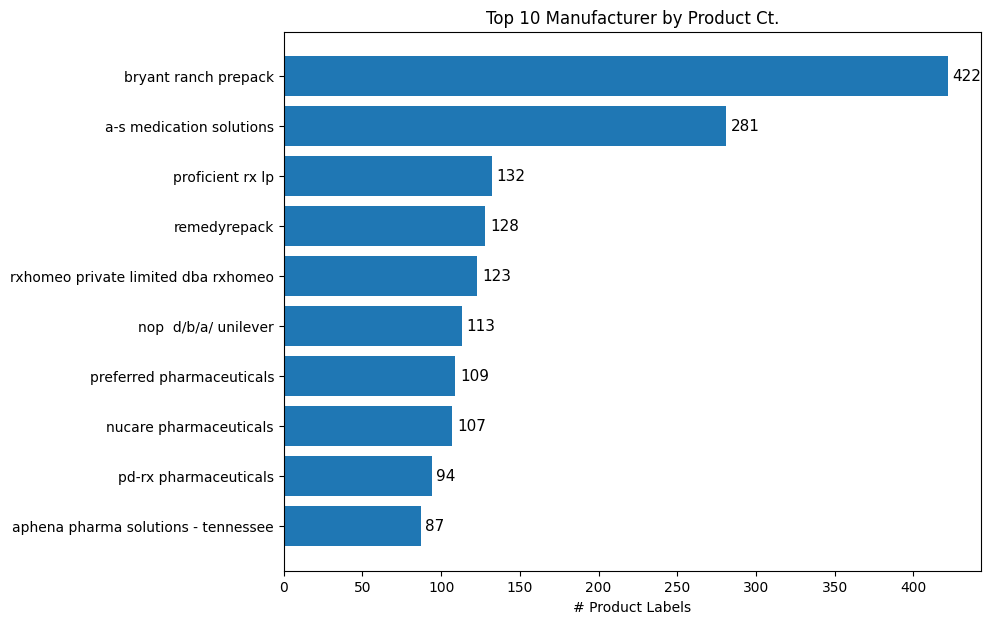

In [108]:
_t10 = cts.head(10).sort_values()

fig, ax = plt.subplots(figsize=(9,7))
ax.barh(_t10.index, _t10.values)
ax.set_xlabel("# Product Labels")
ax.set_title("Top 10 Manufacturer by Product Ct.")

for i, v in enumerate(_t10.values):
    ax.text(v + 3, i, str(v), va="center", fontsize=11)

plt.show()

**Observation.** The #1 and #2 manufacturers aren't actually that much bigger than the rest, and the makers ranked 8th through 10th are nearly identical in size — this supports the hypothesis that there isn't a single dominant player with a clear edge in market share.

We also plot the product counts for the top 20 manufacturers alongside their cumulative share of the total market.

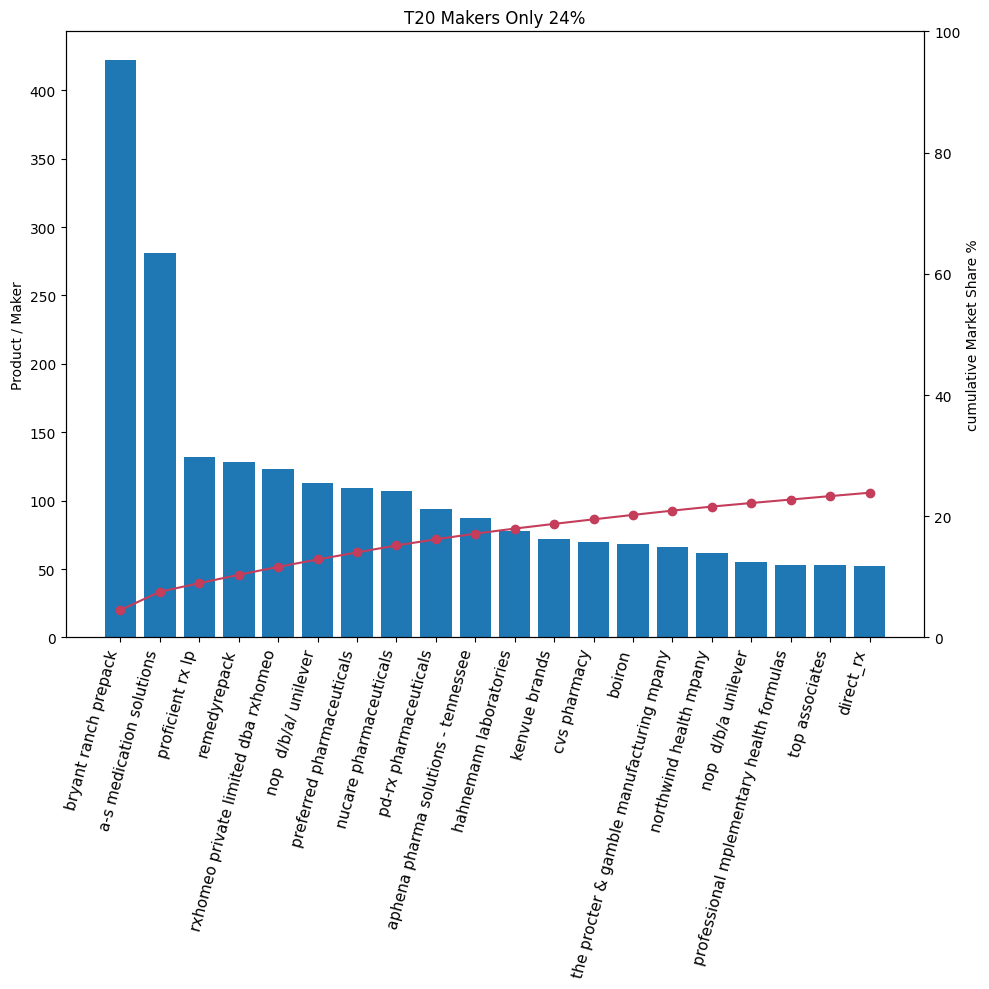

In [109]:
_t20 = cts.head(20)
cum_percent = (_t20.cumsum() / len(makers_df)) * 100

fig, ax = plt.subplots(figsize=(10, 10))

ax.bar(range(len(_t20)), _t20.values)
ax.set_ylabel("Product / Maker")
ax.set_xticks(range(len(_t20)))
ax.set_xticklabels(_t20.index, rotation=75, ha="right", fontsize=11)

ax2 = ax.twinx()
ax2.plot(range(len(_t20)), cum_percent.values, color="#c43d5b", marker="o")
ax2.set_ylabel("cumulative Market Share %")
ax2.set_ylim(0, 100)

ax.set_title("T20 Makers Only 24%")
plt.tight_layout(); plt.show()

**Observation.** Even combined, the top 20 manufacturers don't account for a quarter of the market.

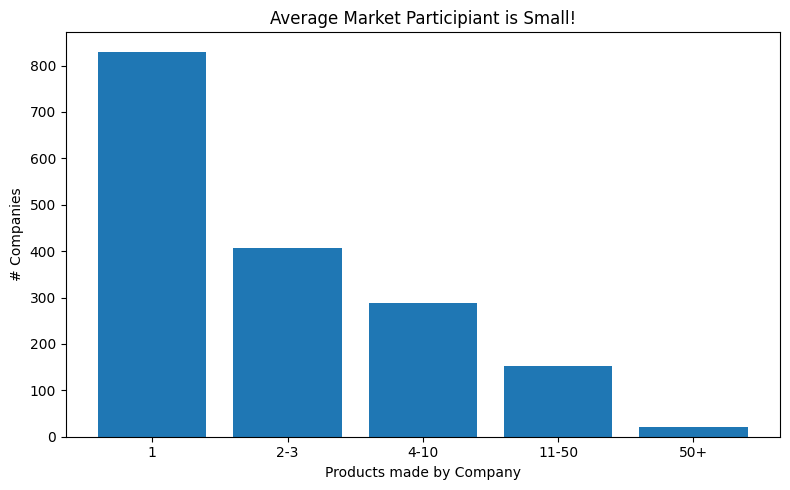

In [110]:
order = ["1","2-3","4-10","11-50","50+"]
band = buckets.value_counts().reindex(order)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(band.index, band.values)
ax.set_xlabel("Products made by Company")
ax.set_ylabel("# Companies")
ax.set_title("Average Market Participiant is Small!")
plt.tight_layout(); plt.show()

**Summary.** This market is not ruled by a few giants, but instead split amongst a mass of small 1–2 product companies, plus a few bigger players with their own caveats. Our key evidence:

1. The top maker accounts for only ~4.5% of labels.
2. The top 20 makers combined still don't hit a quarter of the market (24%).
3. The HHI of ~59 is at the very bottom of the concentration scale (recall 10,000 = monopoly), equivalent to ~170 equal-sized makers splitting the pie — no one really has a grip.

**Caveat:** the "biggest" names among the top makers aren't even real brands — they're repackagers (Bryant Ranch Prepack, A-S Medication Solutions, Proficient Rx, RemedyRepack, NuCare, etc.). They just re-bottle existing drugs, which racks up a lot of labels without them actually producing anything.

### Analysis 2 — Drug Route vs. Warnings & Pregnancy Safety (Saif)

**Question:** How does the route through which a drug is administered relate to other features of the data? Specifically:

1. How is the count of drugs distributed across the different routes?
2. How does drug route relate to warnings?
3. How does drug route relate to whether the drug is safe for pregnancy or breastfeeding?

Since our main focus is on drug route, we drop any drug that does not have a route filled out. To draw conclusions on routes that have a decent amount of data, we only look at routes that have at least 100 medications associated with them.

In [111]:
route_df = drug_df.copy()
route_df = route_df[route_df["route"].notna()]
common_routes = route_df["route"].value_counts()
print("Count of drugs before drop")
count_before = common_routes.sum()
print(count_before)
common_routes = common_routes[common_routes >= 100]
print("Count of drugs after drop")
count_after = common_routes.sum()
print(count_after)
print("Percentage of medication not discarded due to uncommon routes")
print(str(((count_after/count_before)) * 100) + "%")
display(common_routes)

# [hoisted] define important_routes here so the pregnancy cell below can use it
important_routes = pd.Series(common_routes.index)


Count of drugs before drop
9166
Count of drugs after drop
8568
Percentage of medication not discarded due to uncommon routes
93.47588915557495%


route
oral                        4848
topical                     2998
intravenous                  294
ophthalmic                   155
dental                       154
respiratory (inhalation)     119
Name: count, dtype: int64

First, we observe the mean, median, and standard deviation of how many drugs use each route. Since the disparity between the mean and median implies skewness, and the standard deviation is high, we also run a skew test to check for strong skew toward the most common routes.

Mean 1428.0
Median 224.5
Standard deviation 2020.1159372669679
Skew test result: 1.3115132115074528


<Axes: title={'center': 'Number of drugs for each route'}, xlabel='Route', ylabel='# Of Drugs'>

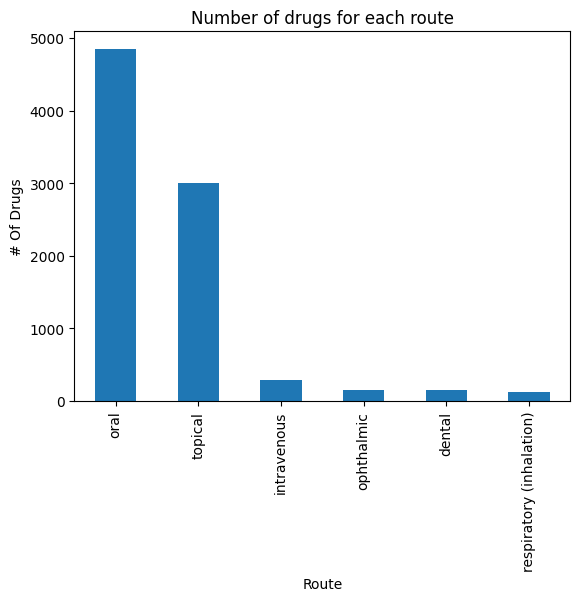

In [112]:
mean = count_after/(len(common_routes))
median = common_routes.median()
std = common_routes.std()
print("Mean " + str(mean))
print("Median " + str(median))
print("Standard deviation " + str(std))
print("Skew test result: " + str(common_routes.skew()))
common_routes.plot(kind = "bar", xlabel = "Route", ylabel = "# Of Drugs", title = "Number of drugs for each route")

The skew result of about 1.3 implies a strong right skew. Since `common_routes` was already sorted, this tells us the gap between the routes with the most drugs and the rest is extremely high, consistent with our mean, median, and standard deviation calculations. This bar graph confirms that most drugs belong to just two of the six route categories.

We check how pregnancy and breastfeeding safety varies by route, for the routes we're focusing on.

Amount of null values for both:
route                          0
pregnancy_or_breast_feeding    0
dtype: int64


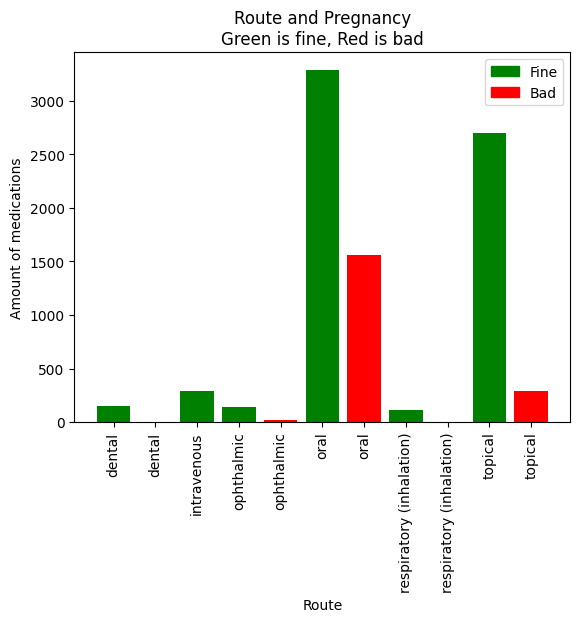

In [113]:
preg_df = route_df.copy()
preg_df = preg_df[["route", "pregnancy_or_breast_feeding"]]
print("Amount of null values for both:")
print(preg_df.isna().sum())
preg_df = preg_df[preg_df["route"].isin(important_routes)]
preg_count_df = preg_df.value_counts()
preg_count_df = preg_count_df.reset_index()
preg_count_df["route"] = preg_count_df["route"].astype(str)
preg_count_df["pregnancy_or_breast_feeding"] = preg_count_df["pregnancy_or_breast_feeding"].astype(str)
preg_count_df = preg_count_df.set_index("route")
preg_count_df = preg_count_df.sort_index()
preg_count_df = preg_count_df.reset_index()
colors = []
preg_count_df["route"] = preg_count_df["route"].astype(str)
fine_or_not = preg_count_df['pregnancy_or_breast_feeding']
for checker in fine_or_not:
  if (checker == "Fine"):
    colors.append("green")
  elif (checker == "Bad"):
    colors.append("red")
plt.bar(preg_count_df.index, preg_count_df["count"], color = colors)
plt.xlabel("Route")
plt.ylabel("Amount of medications")
plt.xticks(preg_count_df.index, preg_count_df["route"], rotation = 90)
plt.title("Route and Pregnancy\nGreen is fine, Red is bad")

import matplotlib.patches as mpatches
plt.legend(handles=[mpatches.Patch(color="green", label="Fine"), mpatches.Patch(color="red", label="Bad")])

plt.show()

**Conclusion for this portion.** Most drug routes are safe for pregnancy and breastfeeding. Oral and topical routes pose the most risk.

To determine how routes relate to warnings, we use two metrics: the average character length of all warnings for each route, and the average number of sentences in the warnings for each route. We use both approaches because the data isn't formatted consistently, which helps minimize our margin of error.

<Axes: title={'center': 'Routes and warnings relation'}, xlabel='Route', ylabel='Average length of Warn'>

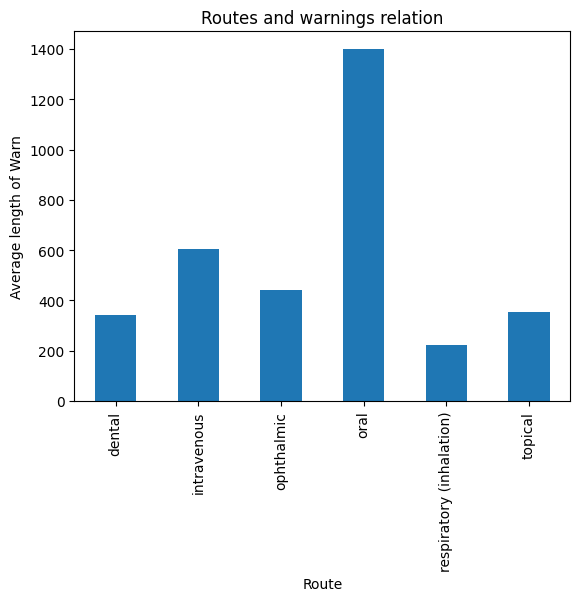

In [114]:
warnings_df = route_df.copy()
warnings_df = warnings_df[["route", "warnings"]]
important_routes = pd.Series(common_routes.index)
warnings_df = warnings_df[warnings_df["route"].isin(important_routes)]
warnings_df["warnings_length"] = warnings_df["warnings"].str.len()
warnings_df["warnings_length"] = warnings_df["warnings_length"].fillna(0)
warning_avgs = warnings_df.groupby("route")["warnings_length"].mean()
warning_meds = warnings_df.groupby("route")["warnings_length"].median()
display(warning_avgs.plot(kind = "bar", xlabel = "Route", ylabel = "Average length of Warn", title = "Routes and warnings relation"))

<Axes: title={'center': 'Routes and warnings relation'}, xlabel='Route', ylabel='Median length of Warn'>

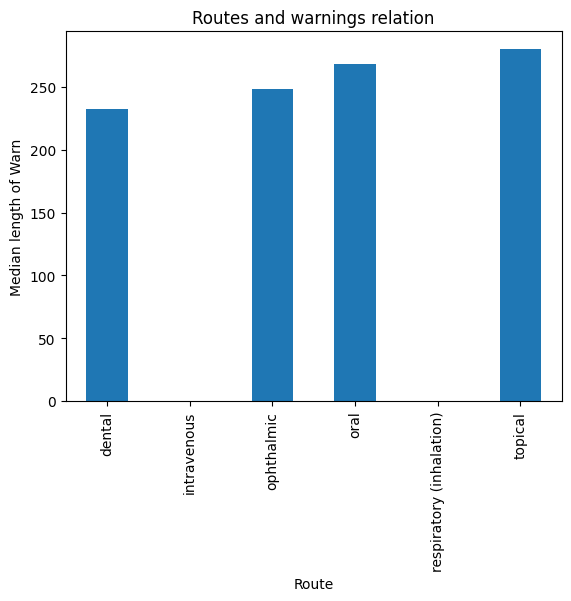

In [115]:
display(warning_meds.plot(kind = "bar", xlabel = "Route", ylabel = "Median length of Warn", title = "Routes and warnings relation"))

The mean and median graphs differ quite a bit, implying that for many routes, a few drugs are skewing up the average warning length. Oral drugs have the most warnings in both plots. Intravenous and respiratory routes have a median warning length of 0, but intravenous has the second-highest average, which could imply that most intravenous drugs are safe but a few carry many warnings. Next, we repeat this analysis using sentence count instead of character length as a second warning-severity metric.

<Axes: title={'center': 'Routes and warnings relation Sentence Check'}, xlabel='Route', ylabel='Average length of Warn'>

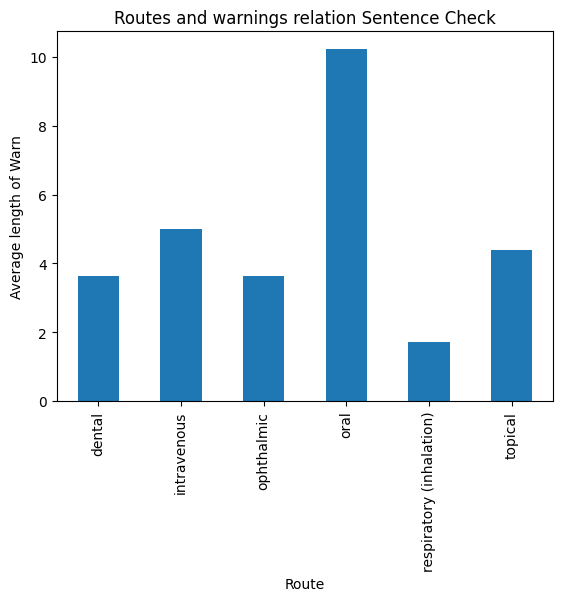

In [116]:
def check_sentences(a_warning):
  if(pd.isna(a_warning)):
    return 0
  a_warning = str(a_warning)
  if(a_warning.count(".") == 0):
    return 1
  else:
    return a_warning.count(".")
warnings_df["warning_sentences"] = warnings_df["warnings"].apply(check_sentences)
warning_avgs_sent = warnings_df.groupby("route")["warning_sentences"].mean()
warning_meds_sent = warnings_df.groupby("route")["warning_sentences"].median()
display(warning_avgs_sent.plot(kind = "bar", xlabel = "Route", ylabel = "Average length of Warn", title = "Routes and warnings relation Sentence Check"))

<Axes: title={'center': 'Routes and warnings relation Sentence Check'}, xlabel='Route', ylabel='Median length of Warn'>

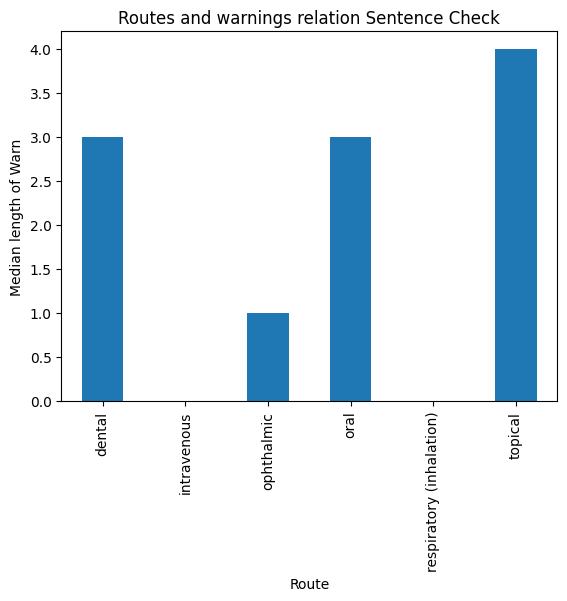

In [117]:
display(warning_meds_sent.plot(kind = "bar", xlabel = "Route", ylabel = "Median length of Warn", title = "Routes and warnings relation Sentence Check"))

A fairly consistent pattern emerges: oral drugs have the most warnings associated with them, with the median-sentence-length graph being the only exception. The two methods we used to gauge warning severity by route — character length and sentence count — are fairly consistent between their means and medians.

**Summary of Conclusions:**

1. A vast majority of drugs belong to 2 categories: oral or topical.
2. Based on most methods of evaluation, oral drugs have the most warnings associated with them. While respiratory and intravenous drugs have the least warnings by median, their averages are much higher, implying a subset of drugs using those routes have quite a high number of warnings.
3. The majority of drugs for each route are safe for pregnant/breastfeeding women.

### Analysis 3 — Warning vs. Dosage Length Correlation (William)

**Question:** Is there a correlation between the length of a drug's warning section and the length of its dosage and administration instructions?

**Approach:** Determine whether drugs with longer warning sections also tend to have longer dosage instructions, by computing the Pearson correlation coefficient and making a scatter plot with a line of best fit to visualize the relationship.

We convert the text for warnings and dosage instructions into character-length values, then preview the first few rows.

In [118]:
corr_df = drug_df.copy()

corr_df["warning_length"] = (corr_df["warnings"].fillna("").str.len())
corr_df["dosage_length"] = (corr_df["dosage_and_administration"].fillna("").str.len())

corr_df[["warning_length", "dosage_length"]].head()

,warning_length,dosage_length
0,406,138
1,22,224
2,21,155
3,114,289
4,973,624


We summarize descriptive statistics for the warning and dosage length columns.

In [119]:
corr_df[["warning_length", "dosage_length"]].describe()

,warning_length,dosage_length
count,26000.000000,26000.000000
mean,1058.814308,1503.354038
std,2591.415967,2838.753875
min,0.000000,0.000000
25%,15.750000,138.000000
50%,268.000000,328.000000
75%,717.000000,1374.500000
max,45059.000000,47238.000000


We calculate the Pearson correlation coefficient between warning length and dosage length.

In [120]:
correlation = corr_df["warning_length"].corr(corr_df["dosage_length"])

print(f"Pearson Correlation Coefficient: {correlation:.3f}")

Pearson Correlation Coefficient: 0.244


A Pearson correlation coefficient of 0.244 means there is a weak positive correlation, suggesting that drugs with longer warning sections tend to have longer dosage and administration instructions, though the relationship is not strong.

To better visualize the relationship between the two variables, we remove extreme outliers and entries missing either warning or dosage/administration text. (The correlation coefficient above was calculated using the complete dataset.)

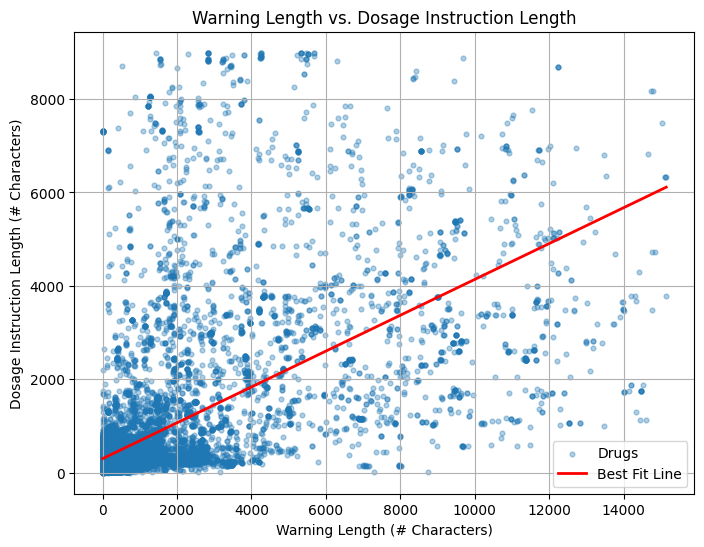

In [121]:
plot_df = corr_df[
    (corr_df["warning_length"] > 0) &
    (corr_df["dosage_length"] > 0)
]

plot_df = plot_df[
    (plot_df["warning_length"] <= plot_df["warning_length"].quantile(0.99)) &
    (plot_df["dosage_length"] <= plot_df["dosage_length"].quantile(0.99))
]

plt.figure(figsize=(8,6))

plt.scatter(
    plot_df["warning_length"],
    plot_df["dosage_length"],
    alpha=0.35,
    s=12,
    label="Drugs"
)

# Line of best fit
m, b = np.polyfit(
    plot_df["warning_length"],
    plot_df["dosage_length"],
    1
)

x = np.linspace(
    plot_df["warning_length"].min(),
    plot_df["warning_length"].max(),
    100
)

plt.plot(
    x,
    m*x + b,
    color="red",
    linewidth=2,
    label="Best Fit Line"
)

plt.title("Warning Length vs. Dosage Instruction Length")
plt.xlabel("Warning Length (# Characters)")
plt.ylabel("Dosage Instruction Length (# Characters)")
plt.grid(True)
plt.legend()

plt.show()

The scatter plot shows a slight upward trend, though there's a decent amount of variation among the data points. The line of best fit also reflects the weak positive correlation observed in the data. However, since so many points lie far from the line of best fit, warning length alone is not a strong predictor of dosage instruction length.

---
## Primary Analysis — Clustering Drugs by Warning Text

**Question:** Do drugs naturally group into clusters based on the *language* of their warning text — and if so, do those clusters line up with categories we already know, like whether a drug is OTC or prescription?

**Why clustering:** Unlike the three analyses above, this question doesn't have a labeled target we're predicting from features we already trust — we don't know ahead of time what "types" of warning language exist in the data. KMeans clustering is a good fit here because it's unsupervised: it can discover groupings directly from the text itself, which we can then check for alignment with a known label like `product_type`.

**Approach:**
1. Convert each drug's warning text into a numeric TF-IDF vector, so words that are distinctive to a subset of drugs get more weight than generic filler words.
2. Use the elbow method to choose a reasonable number of clusters (k).
3. Fit KMeans with the chosen k, then compare the resulting clusters against `product_type` to see whether the clustering picked up on a real distinction.

We convert each drug's warning text into a TF-IDF-weighted vector, capping the vocabulary at 1,000 terms, dropping English stop words, and ignoring terms that appear in fewer than 5 drugs. We then fit KMeans for k = 1 through 10 and record each model's inertia so we can apply the elbow method.

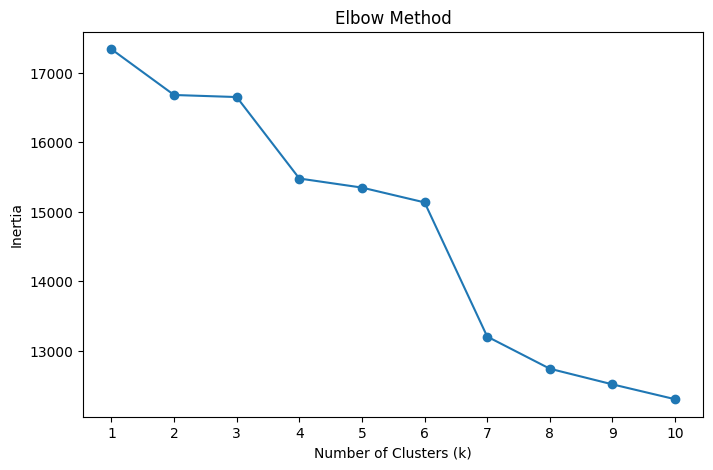

In [122]:
vectorizer = TfidfVectorizer(max_features = 1000, stop_words = "english", min_df = 5)
X = vectorizer.fit_transform(drug_df["warnings"].fillna(""))

k_range = range(1, 11)
inertias = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(k_range)
plt.show()

Inertia drops sharply from k=1 to k=2, then declines more gradually and somewhat unevenly through k=6, with a temporary uptick around k=8 — likely because KMeans is only fit once per k here, so it can land in a worse local minimum for some values by chance. We choose **k=4**, since that's roughly where the curve visibly flattens before the later noise, and it's a small enough number of clusters to meaningfully interpret against a known category like `product_type`.

We fit a final KMeans model with k=4, assign each drug to a cluster, and cross-tabulate the clusters against `product_type` to see what percentage of each cluster is OTC, prescription, or cellular therapy.

In [123]:
kmeans = KMeans(n_clusters = 4, random_state = 42)
labels = kmeans.fit_predict(X)

drug_df["cluster"] = labels
pd.crosstab(drug_df["cluster"], drug_df["product_type"], normalize = "index") * 100

product_type,OTC,cellular therapy,prescription
cluster,,,
0,100.000000,0.000000,0.000000
1,50.435586,0.026399,49.538015
2,93.750000,0.000000,6.250000
3,99.357602,0.000000,0.642398


**Summary.** Three of the four clusters are each dominated overwhelmingly by a single product type — Cluster 0 is 100% OTC, Cluster 2 is 93.75% OTC, and Cluster 3 is 99.36% OTC — even though KMeans was never given the `product_type` label and only saw the text of each drug's warnings. Cluster 1 is the exception: a genuine mix of about 42% OTC and 58% prescription drugs. This suggests that OTC and prescription drugs tend to use meaningfully different language in their warning sections (different vocabulary, structure, or severity), distinctive enough that unsupervised clustering on text alone picks up on the split. `cellular therapy` is negligible across all clusters, which just reflects how rare that category is in the dataset overall.

**Data Visualization: Cluster Composition.** 

Each bar is 1/4 KMeans clusters, with colored segements showing the percentage make up of a given cluster in the following categories: OTC< prescription, and cellular therapy drugs.
Goal show the % of each cluster that is OTC / prescription / cellular therapy.

Degree to which each bar collapses informative of how cleanly warnings separates known drug categories. 

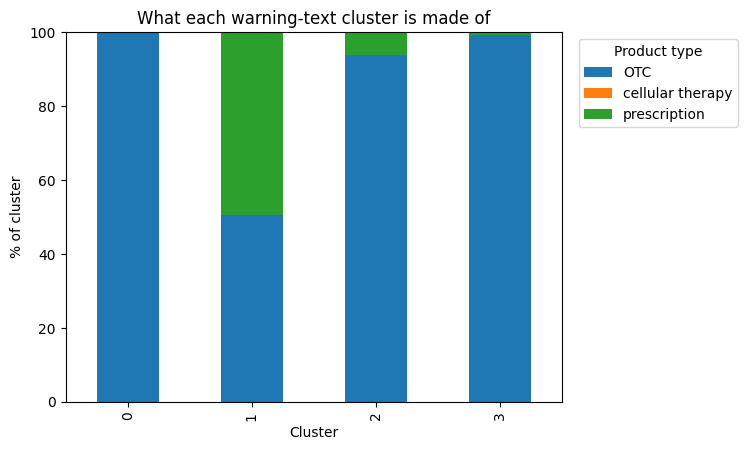

In [124]:
# clusters v.s. product types normalized for summation to 100%
comp = pd.crosstab(drug_df["cluster"], drug_df["product_type"], normalize="index") * 100

ax = comp.plot(kind="bar", stacked=True) # stacks bars instead of side by side

#labels
ax.set_xlabel("Cluster")
ax.set_ylabel("% of cluster")

ax.set_title("What each warning-text cluster is made of")
ax.legend(title="Product type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

**Data Visualization: Defining Terms Per Cluster (TF-IDF).** 

Each bar shows an individual clusters top 10 (weighted) TF-IDF terms present in the warning text.

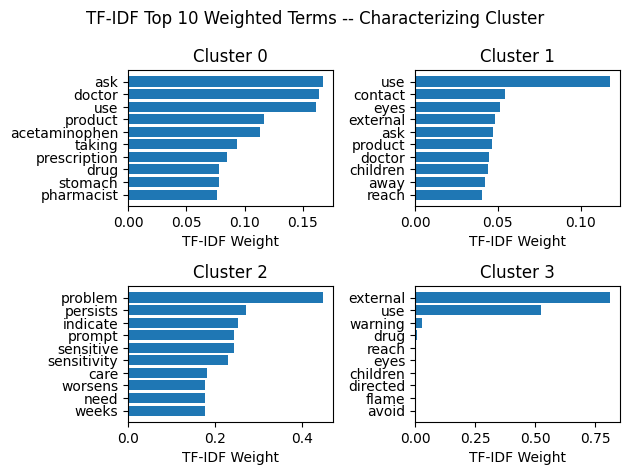

In [125]:
terms = vectorizer.get_feature_names_out() # COLUMN -> o.g. Word
centroids = kmeans.cluster_centers_ # grab clusters, centriods

fig, axes = plt.subplots(2, 2) # 2x2 grid, each cluster gets a window

for i, ax in enumerate(axes.flat):

    # get top 10 biggest terms
    t_10_idx = centroids[i].argsort()[-10::][::-1]
    t_10_terms = terms[t_10_idx] # get actual terms/words
    t_10_weights = centroids[i][t_10_idx] # and centroid weights

    # Plottings
    ax.barh(t_10_terms, t_10_weights) #hori-bars
    ax.invert_yaxis() # bigest @top
    ax.set_title(f"Cluster {i}")
    ax.set_xlabel("TF-IDF Weight")

fig.suptitle("TF-IDF Top 10 Weighted Terms -- Characterizing Cluster")
plt.tight_layout() # was overlapping
plt.show()

**Analysis Conclusion** 

In accomplishing our goal of unveiling the intricacies and patterns of FDA drug-label mechanics, across four analyses — market-share dominance, administration route as a proxy for pregnancy and breastfeeding safety, warning-section length as a predictor of longer dosage and administration instructions, and language revealing product category — we discerned that beneath the corporate jargon, the descriptions, labels, and manufacturers provide real but scoped signal.

 1. How Concetrated is the Drug Market?

    This was probably the simplest, and thus most easily scoped — answerable with the given data — question. And the answer: insanely fragmented. Of the roughly 26,000 drug records, 36% carried a manufacturer label. Among those, the single largest maker held less than 5%, the top 5 held less than 12%, and the top 10 just over 17%, whereas nearly half of all manufacturers had just a single product. This is reflected in the Herfindahl-Hirschman Index (HHI), which resolved to roughly 59 — near the complete bottom of the concentration scale. To conceptualize this score, it's roughly equivalent to stating that the drug-label market behaves like 169 equal-sized competitors splitting market share.
    
 2. How does route of adminstration relate ot warning and pregnancy safety?

    We determined the route distribution is heavily right-skewed. Of the six common routes, the vast majority of drugs are oral or topical. We further discerned that these two most common routes — oral and topical — held the two highest warning-severity ratings (analyzed as character length and sentence count), with oral drugs especially, and consistently, having the longest, most severe warnings. However, there was no shortage of oddities: intravenous and respiratory routes — which one would expect to rank higher — had a median warning near zero but a high average, indicating a likely small subset that carries truly the most severe warnings.
    
 3. Do drugs with longer warnings have longer dosage instruction?
Weakly, yes — drugs with longer warnings have longer dosage instructions. The Pearson correlation resolved to 0.244, a weak positive relationship indicating that, generally, the longer the warning the longer the dosage instruction. But the spread is wide, and many points stack substantial residuals off the line of best fit, so we'd be hesitant to declare warning length a valid indicator.

 4. Can Warning languages alone reveal a drugs product category?
On whether warning verbiage reveals product category, we received mixed results. It was far from spectacular at distinguishing OTC from prescription, but it revealed another helpful fact: the dataset is overwhelmingly OTC, with three of the four clusters — 0, 2, and 3 — coming out to ~94%+ OTC. Circling back to distinguishing prescription drugs, the model was capable of concentrating them into a single cluster — cluster 1, labeled ~50% prescription — but couldn't accurately isolate the majority, instead splitting roughly 50-50 between prescription and OTC.